# IIoT Network Analysis: Age of Information and Reliability Trade-offs

In [19]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf

In [20]:
# Load the dataset
df = pd.read_csv('iiot_network_data.csv')

# 1. Conceptual Understanding (20 points)

"""
Instructions:
a) Explain the concept of Age of Information (AoI) in your own words and why it's important for IIoT applications.
b) Describe the difference between AoI-oriented traffic and deadline-oriented traffic in IIoT networks. Provide real-world examples for each.

Write your answers here:

a) Age of Information (AoI) explanation:


b) AoI-oriented vs deadline-oriented traffic:


# 2. Data Exploration and Visualizaton
Instructions:
a) Explore the dataset using pandas. Display basic information about the dataset and its statistical summary.
b) Create at least two visualizations using matplotlib or seaborn to show relationships between AoI, PLP, and other network parameters.
c) Identify and discuss any patterns or trends you observe in the data.

Complete the code below and add your observations.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 10000 non-null  object 
 1   node_id                   10000 non-null  int64  
 2   traffic_type              10000 non-null  object 
 3   transmission_probability  10000 non-null  float64
 4   capture_threshold         10000 non-null  float64
 5   num_nodes                 10000 non-null  int64  
 6   channel_quality           10000 non-null  float64
 7   age_of_information        10000 non-null  float64
 8   packet_loss_probability   10000 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 703.3+ KB
None
            node_id  transmission_probability  capture_threshold  \
count  10000.000000              10000.000000       10000.000000   
mean      50.638400                  0.548460          -0.001800   
std       29.02

<Figure size 1200x600 with 0 Axes>

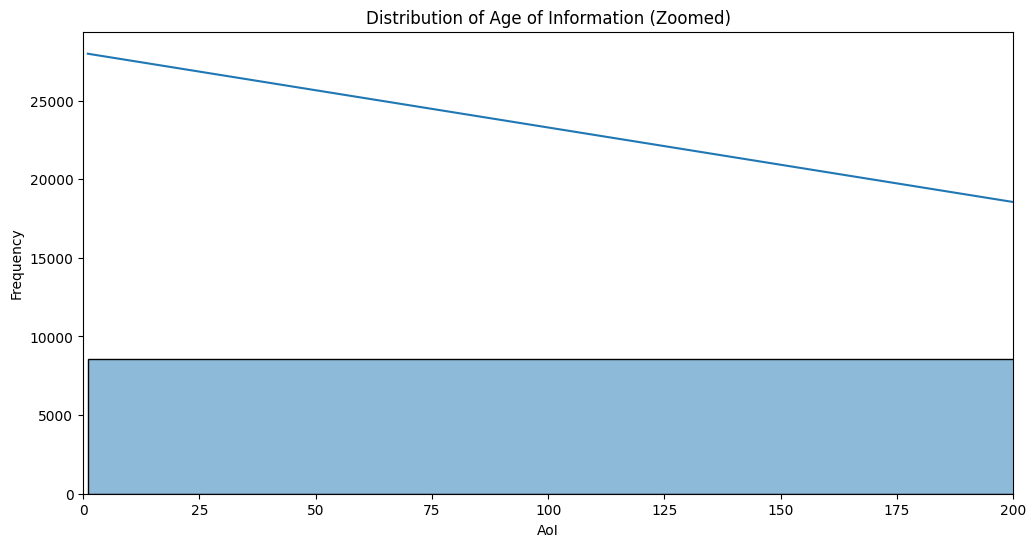

<Figure size 1200x600 with 0 Axes>

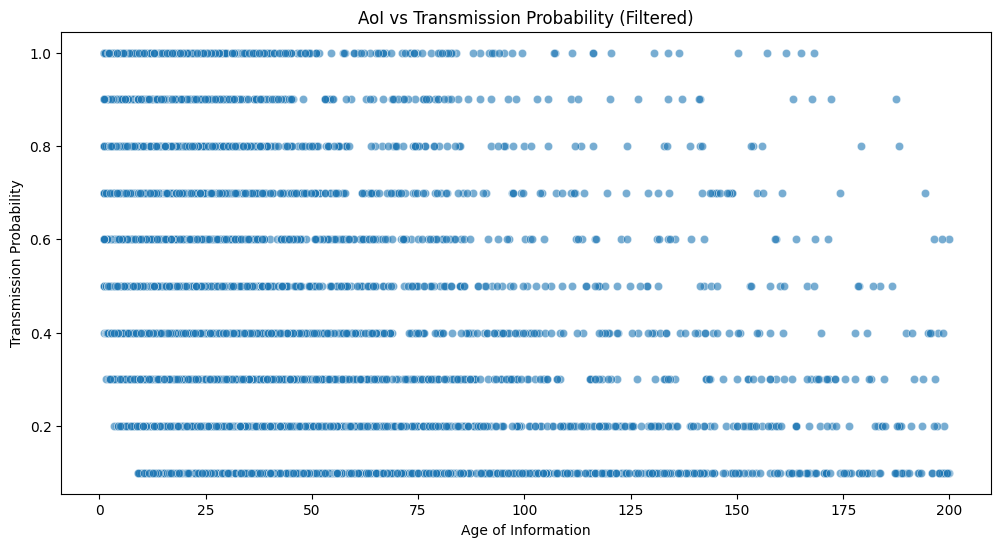

In [21]:
# Display basic information about the dataset
print(df.info())
print(df.describe())

# Create visualizations
plt.figure(figsize=(12, 6))
# Add your code here to create a scatter plot of transmission_probability vs age_of_information
plt.figure(figsize=(12,6))
sns.histplot(df['age_of_information'], bins=30, kde=True)
plt.xlim(0, 200)  # zoom in
plt.title('Distribution of Age of Information (Zoomed)')
plt.xlabel('AoI')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(12, 6))
# Add your code here to create another relevant visualization
# Remove extreme outliers for better visualization
filtered_df = df[df['age_of_information'] < 200]

plt.figure(figsize=(12,6))
sns.scatterplot(
    x='age_of_information',
    y='transmission_probability',
    data=filtered_df,
    alpha=0.6
)

plt.title('AoI vs Transmission Probability (Filtered)')
plt.xlabel('Age of Information')
plt.ylabel('Transmission Probability')
plt.show()

# Add more visualizations as needed



## Write your observations about the data and visualizations here:

# 3. Machine Learning Model Development (35 points)

Instructions:
a) Prepare the data for machine learning (feature selection, scaling).
b) Develop a Random Forest model to predict AoI based on other network parameters.
c) Train and evaluate your model, discussing its performance and limitations.
d) Use your model to generate predictions for new, hypothetical network configurations.

Complete the code below and add your analysis.

In [24]:
import numpy as np
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# Prepare the data
X = df[['transmission_probability', 'capture_threshold', 'num_nodes', 'channel_quality']]
y_aoi = df['age_of_information']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_aoi, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest model
rf_model.fit(X_train_scaled, y_train)



RandomForestRegressor(random_state=42)

In [25]:
# Make predictions
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2 Score:", r2)

# Feature importance
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

MSE: 3423000.629784774
R2 Score: -0.5546162432715187
                    Feature  Importance
1         capture_threshold    0.440095
2                 num_nodes    0.315242
3           channel_quality    0.153468
0  transmission_probability    0.091195


## Write your analysis of the model performance and feature importances here:


In [26]:
# Generate predictions for new, hypothetical network configurations:


# Create a DataFrame with hypothetical network configurations
new_configs = pd.DataFrame({
    'transmission_probability': [0.5, 0.7, 0.9],
    'capture_threshold': [0, 1, -1],
    'num_nodes': [3, 5, 7],
    'channel_quality': [0.6, 0.8, 0.4]
})

# Scale the new data
new_configs_scaled = scaler.transform(new_configs)

# Make predictions
new_predictions = rf_model.predict(new_configs_scaled)

print("Predicted AoI for new configurations:")
print(new_predictions)


Predicted AoI for new configurations:
[10.60661488 16.05402712 11.20560361]


# 4. Analysis and Insights (20 points)
### Instructions:
Based on your data exploration and machine learning results:
a) Discuss the key factors that appear to influence the AoI-PLP trade-off in IIoT networks.
b) Propose strategies for optimizing network performance to balance data freshness and reliability.
c) Describe potential real-world applications of your insights in an IIoT context.

Write your analysis and insights here:

The results show that capture threshold and number of nodes seem to have the biggest impact on Age of Information. As the number of nodes increases, the network can get more congested, which leads to higher AoI and less fresh data. The capture threshold also plays a role because it affects how easily signals are received, which impacts overall performance.

To improve network performance, things like better channel quality, adjusting transmission probability, and reducing congestion can help balance data freshness and reliability. For example, tuning the transmission probability can help lower packet loss while still keeping updates timely.

These ideas can be useful in real-world IIoT systems like smart factories, healthcare monitoring, and environmental sensors, where having up-to-date information is really important for making decisions and keeping systems running efficiently.

# 5. Bonus Challenge (10 points)

"""
Instructions:
Implement a simple deep learning model (e.g., a basic neural network) to predict both AoI and PLP simultaneously.
Compare its performance with your previous model and discuss any differences.

Complete the code below and add your analysis.

In [27]:
# Prepare data for deep learning model
y_plp = df['packet_loss_probability']
X_train, X_test, y_aoi_train, y_aoi_test, y_plp_train, y_plp_test = train_test_split(
    X, y_aoi, y_plp, test_size=0.2, random_state=42)

In [28]:
# Create a simple neural network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2)  # Output layer for AoI and PLP
])

model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train,
          np.column_stack((y_aoi_train, y_plp_train)),
          epochs=10,
          batch_size=32,
          verbose=1)

# Add your code here to fit the model
# Evaluate the model

# Make predictions
predictions = model.predict(X_test)

# Split outputs
pred_aoi = predictions[:, 0]
pred_plp = predictions[:, 1]

# Calculate MSE
mse_aoi = mean_squared_error(y_aoi_test, pred_aoi)
mse_plp = mean_squared_error(y_plp_test, pred_plp)

print("AoI MSE:", mse_aoi)
print("PLP MSE:", mse_plp)



Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 669431.5625
Epoch 2/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 666247.3750
Epoch 3/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 665546.1875 
Epoch 4/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 665258.1250
Epoch 5/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 664965.7500
Epoch 6/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 664766.8750
Epoch 7/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 664470.7500
Epoch 8/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 664352.3750
Epoch 9/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 664042.5000
Epoch 10/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 663765.1250
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
AoI MSE: 2198209.233111726
PLP MSE: 0.020775390524845342


## Write your comparison of the deep learning model with the Random Forest model here:
The neural network model was used to predict both Age of Information and packet loss probability at the same time. Compared to the Random Forest model, the neural network showed mixed performance.

The model produced a relatively high MSE for AoI, which indicates that it struggled to accurately predict Age of Information. However, the MSE for packet loss probability was much lower, showing that the model performed better when predicting PLP.

One reason for this difference could be that AoI has more variability and extreme values, making it harder for the model to learn patterns. In comparison, packet loss probability appears to be more stable and easier to predict.

Overall, the Random Forest model was more reliable for predicting AoI, while the neural network performed better for PLP. This shows that different models may be better suited for different types of network metrics.